  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_20412\3353299334.py:13: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('Interest Rate and Inflation Rate.csv', parse_dates=['Date'])


100%|██████████| 50/50 [00:38<00:00,  1.28trial/s, best loss: 0.7010992908446201]
Training Metrics: {'RMSE': np.float64(0.020711560930770673), 'MAE': 0.014691869781430158, 'R²': 0.9999224750959641, 'MAPE': np.float64(0.2378638131218744)}

Test Metrics: {'RMSE': np.float64(0.059213736676206614), 'MAE': 0.045699298007882784, 'R²': 0.9959970036883257, 'MAPE': np.float64(0.9679012470658814)}


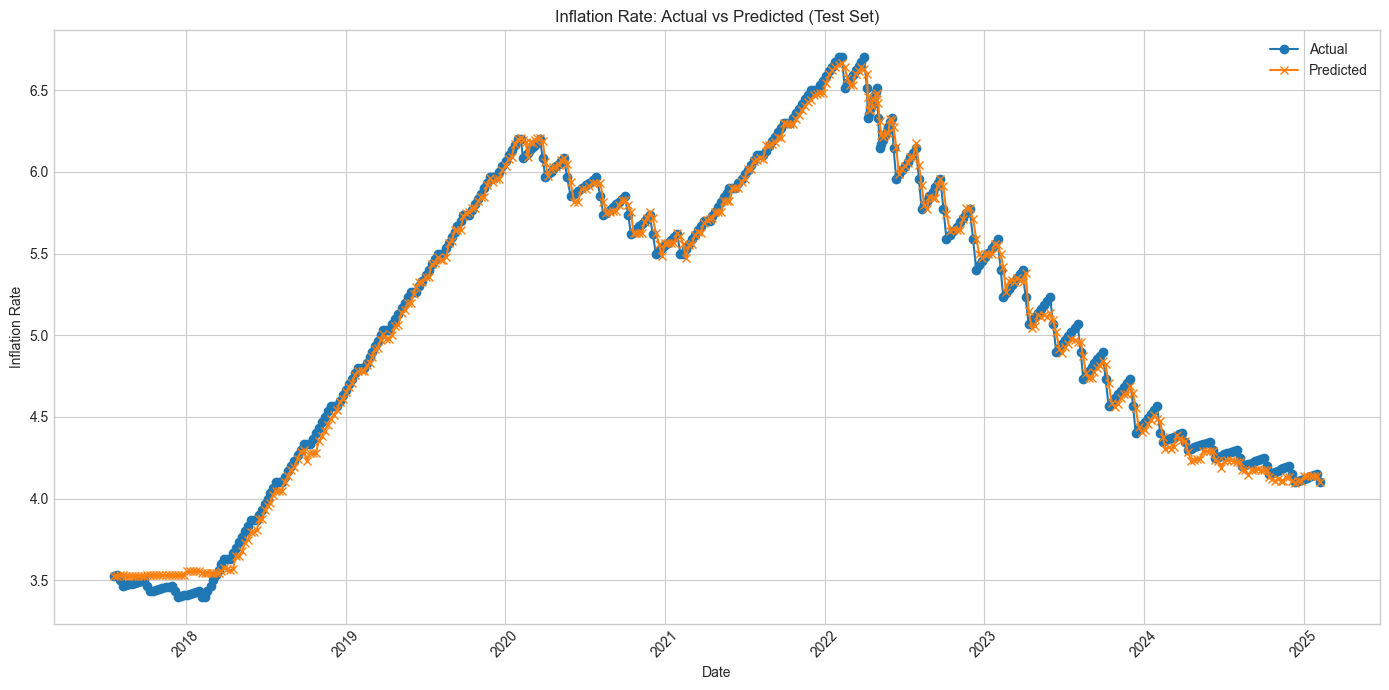

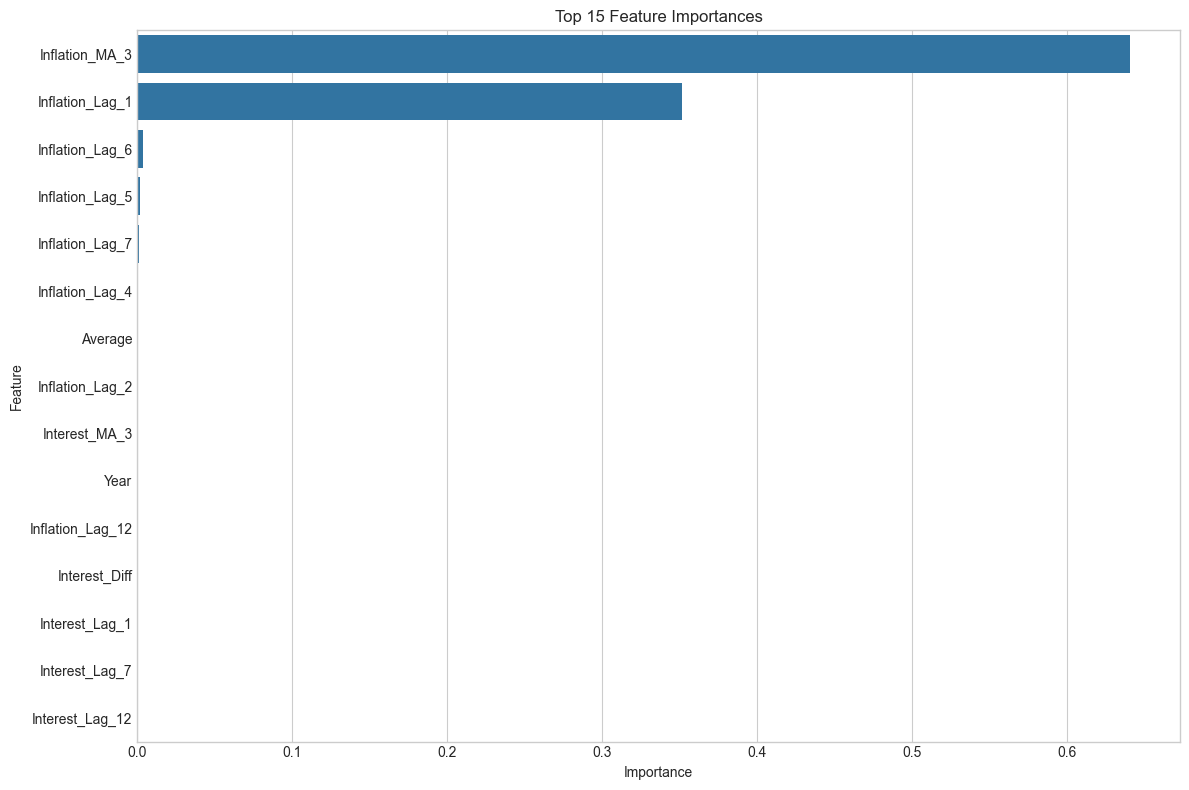

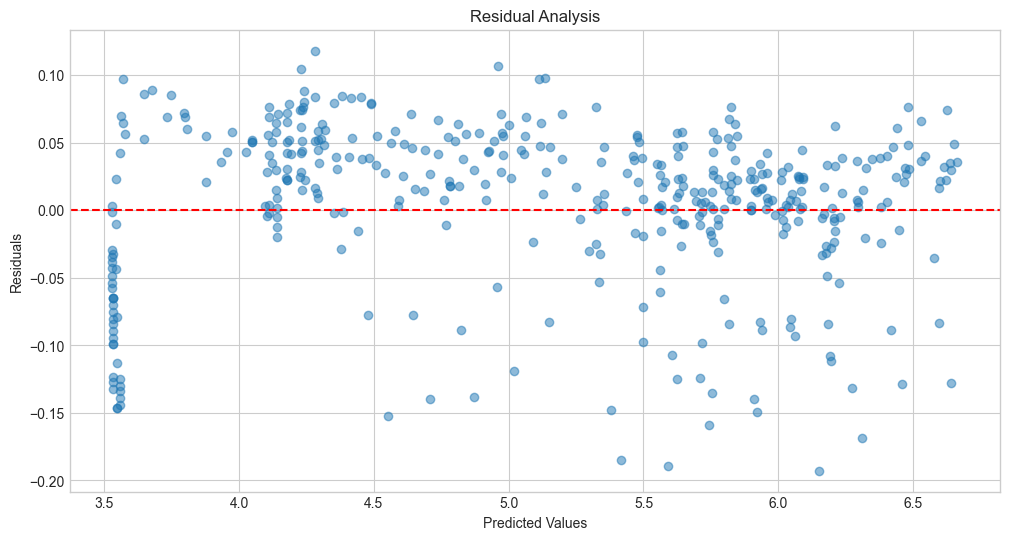

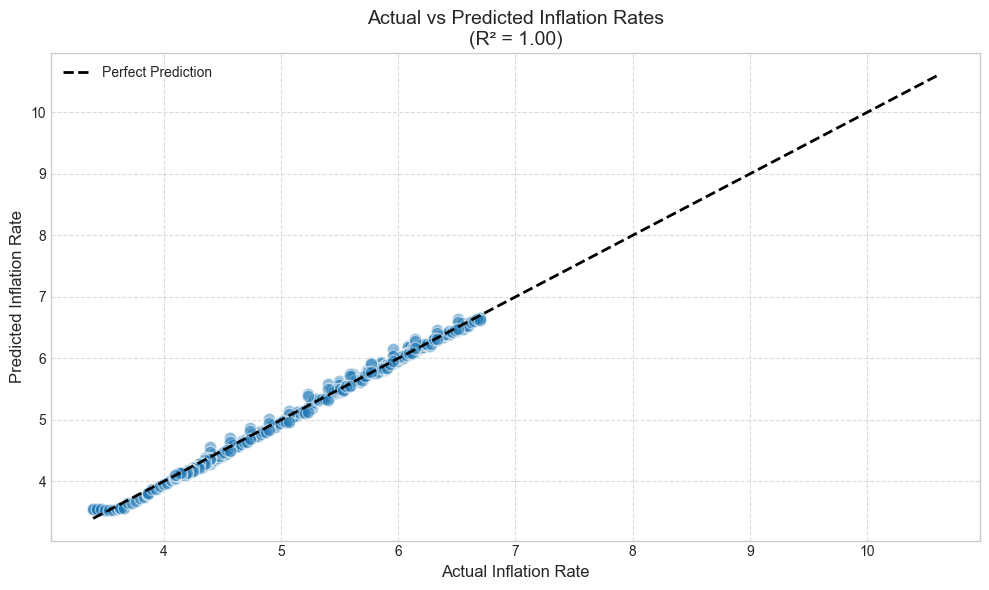

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Load and preprocess data
df = pd.read_csv('Interest Rate and Inflation Rate.csv', parse_dates=['Date'])
df = df.sort_values('Date').dropna().reset_index(drop=True)

# Enhanced Feature Engineering
for lag in [1, 2, 3, 4, 5, 6, 7, 12]:  # Multiple time lags
    df[f'Interest_Lag_{lag}'] = df['Average'].shift(lag)
    df[f'Inflation_Lag_{lag}'] = df['Inflation Rate'].shift(lag)

# Rolling statistics
df['Interest_MA_3'] = df['Average'].rolling(3).mean()
df['Interest_MA_7'] = df['Average'].rolling(7).mean()
df['Inflation_MA_3'] = df['Inflation Rate'].rolling(3).mean()

# Time-based features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year

# Differencing to handle non-stationarity
df['Interest_Diff'] = df['Average'].diff()
df['Inflation_Diff'] = df['Inflation Rate'].diff()

df = df.dropna()

# Prepare data
X = df.drop(['Inflation Rate', 'Date', 'Inflation_Diff'], axis=1)
y = df['Inflation Rate']

# Time-based train-test split
test_size = int(len(df) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modified hyperparameter space and model training
space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'max_depth': hp.choice('max_depth', range(3, 11)),
    'subsample': hp.uniform('subsample', 0.6, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 10),  # Correct XGBoost parameter name
    'reg_lambda': hp.uniform('reg_lambda', 0, 10)  # Correct XGBoost parameter name
}

def objective(params):
    # Ensure integer parameters are properly cast
    int_params = ['max_depth']
    for param in int_params:
        if param in params:
            params[param] = int(params[param])
    
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=2000,
        **params,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    
    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train_scaled):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold,
                      eval_set=[(X_val_fold, y_val_fold)],
                      verbose=False)
            
            preds = model.predict(X_val_fold)
            rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
            scores.append(rmse)
        except Exception as e:
            return {'loss': np.inf, 'status': STATUS_FAIL}
    
    return {'loss': np.mean(scores), 'status': STATUS_OK}

# Rest of the code remains the same...

# Run optimization
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials)

# Train final model with best parameters
best_params = {
    'learning_rate': best['learning_rate'],
    'max_depth': range(3, 11)[best['max_depth']],  # Get actual value from choice
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],  # Match parameter name
    'reg_lambda': best['reg_lambda']  # Match parameter name
}

final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2000,
    **best_params,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

final_model.fit(X_train_scaled, y_train,
                eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
                verbose=False)

# Save artifacts
joblib.dump(final_model, 'optimized_inflation_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Evaluation
def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    }

train_metrics = evaluate(y_train, final_model.predict(X_train_scaled))
test_metrics = evaluate(y_test, final_model.predict(X_test_scaled))

print("Training Metrics:", train_metrics)
print("\nTest Metrics:", test_metrics)

# Enhanced Visualizations
plt.figure(figsize=(14, 7))
plt.plot(df['Date'][-test_size:], y_test, label='Actual', marker='o')
plt.plot(df['Date'][-test_size:], final_model.predict(X_test_scaled), 
         label='Predicted', marker='x')
plt.title('Inflation Rate: Actual vs Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('enhanced_time_series_comparison.png')
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance.head(15))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('enhanced_feature_importance.png')
plt.show()

# Residual Analysis
residuals = y_test - final_model.predict(X_test_scaled)
plt.figure(figsize=(12, 6))
plt.scatter(final_model.predict(X_test_scaled), residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residual Analysis')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.savefig('residual_analysis.png')
plt.show()

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_model.predict(X_test_scaled), alpha=0.5, edgecolors='w', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Inflation Rate', fontsize=12)
plt.ylabel('Predicted Inflation Rate', fontsize=12)
plt.title(f'Actual vs Predicted Inflation Rates\n(R² = {test_metrics["R²"]:.2f})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_scatter.png')
plt.show()

In [2]:
# Add this to your training code before saving the model
import pandas as pd
import joblib

df = pd.read_csv('Interest Rate and Inflation Rate.csv', parse_dates=['Date'])
df = df.sort_values('Date').dropna().reset_index(drop=True)

# Enhanced Feature Engineering
for lag in [1, 2, 3, 4, 5, 6, 7, 12]:  # Multiple time lags
    df[f'Interest_Lag_{lag}'] = df['Average'].shift(lag)
    df[f'Inflation_Lag_{lag}'] = df['Inflation Rate'].shift(lag)

# Rolling statistics
df['Interest_MA_3'] = df['Average'].rolling(3).mean()
df['Interest_MA_7'] = df['Average'].rolling(7).mean()
df['Inflation_MA_3'] = df['Inflation Rate'].rolling(3).mean()

# Time-based features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year

# Differencing to handle non-stationarity
df['Interest_Diff'] = df['Average'].diff()
df['Inflation_Diff'] = df['Inflation Rate'].diff()

df = df.dropna()

X = df.drop(['Inflation Rate', 'Date', 'Inflation_Diff'], axis=1)
feature_names = X.columns.tolist()  # Get the exact feature names from training
joblib.dump(feature_names, 'feature_names.pkl')  # Save feature names

C:\Users\Admin\AppData\Local\Temp\ipykernel_14732\1912142432.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('Interest Rate and Inflation Rate.csv', parse_dates=['Date'])


['feature_names.pkl']

In [3]:
# Add to your training code before saving the model
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']